This EDA lab analyzes stock price data from Yahoo Finance using Python.  
We explore trends, distributions, and relationships in the data.

Dataset: Apple Inc.(AAPL)

In [38]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [40]:
df = yf.download("AAPL", start="2022-01-01", end="2024-01-01")
df.columns = df.columns.get_level_values(0)

df = df.reset_index()

[*********************100%***********************]  1 of 1 completed


Open: Price at market open
Close: Price at market close
High: Highest price during the day
Low: Lowest price during the day
Volume: Number of shares traded

These variables help us understand price movement, volatility, and trading activity.

In [41]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    501 non-null    datetime64[ns]
 1   Close   501 non-null    float64       
 2   High    501 non-null    float64       
 3   Low     501 non-null    float64       
 4   Open    501 non-null    float64       
 5   Volume  501 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 23.6 KB


Price,Date,Close,High,Low,Open,Volume
count,501,501.000000,501.000000,501.000000,501.000000,5.010000e+02
mean,2022-12-31 15:37:00.359281408,161.129994,162.793581,159.304201,160.970297,7.359559e+07
min,2022-01-03 00:00:00,123.046814,125.753411,122.210227,124.021172,2.404830e+07
25%,2022-07-05 00:00:00,146.783524,148.390503,144.907202,146.271118,5.414710e+07
50%,2022-12-30 00:00:00,162.036774,163.235219,159.714674,161.644831,6.924600e+07
75%,2023-07-03 00:00:00,174.040283,175.522935,172.132633,174.013387,8.670910e+07
max,2023-12-29 00:00:00,196.073090,197.567559,194.974489,195.984019,1.826020e+08
std,NaN,17.727056,17.459411,17.989137,17.759346,2.536654e+07


In [42]:
df["Movement"] = np.where(df["Close"] > df["Open"], "Up", "Down")

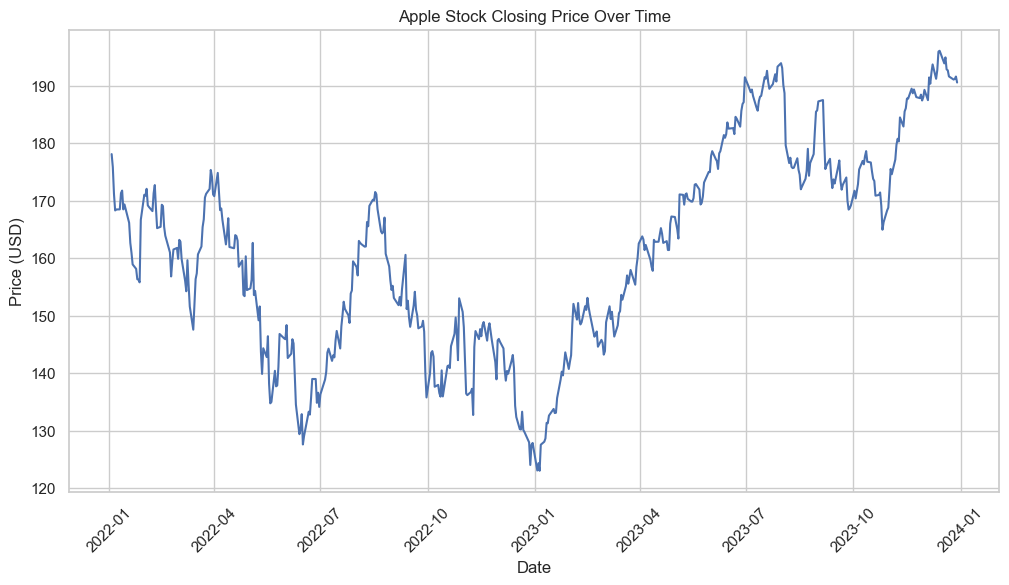

In [43]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"])
plt.title("Apple Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.show()

The stock price shows how Apple’s value changes over time. 
We can observe general trends such as growth or decline periods.

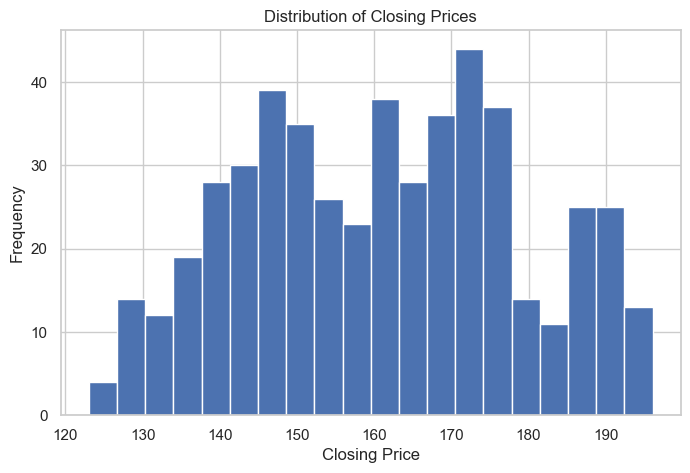

In [44]:
plt.figure(figsize=(8,5))
plt.hist(df["Close"], bins=20)
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

The histogram shows how frequently certain price ranges occur. 
Most prices are concentrated in a specific range, with fewer extreme values.

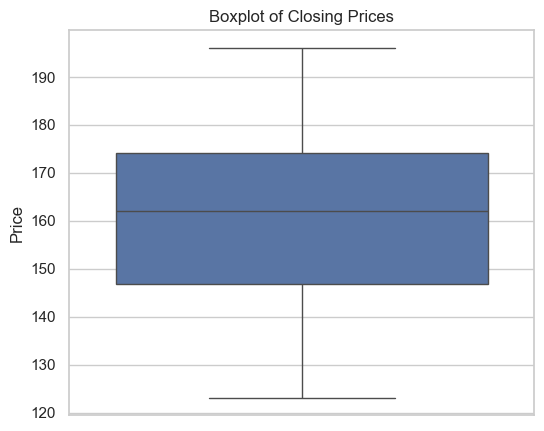

In [45]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df["Close"])
plt.title("Boxplot of Closing Prices")
plt.ylabel("Price")
plt.show()

The boxplot shows the median, quartiles, and outliers. 
Outliers represent unusual price values, possibly due to market events.

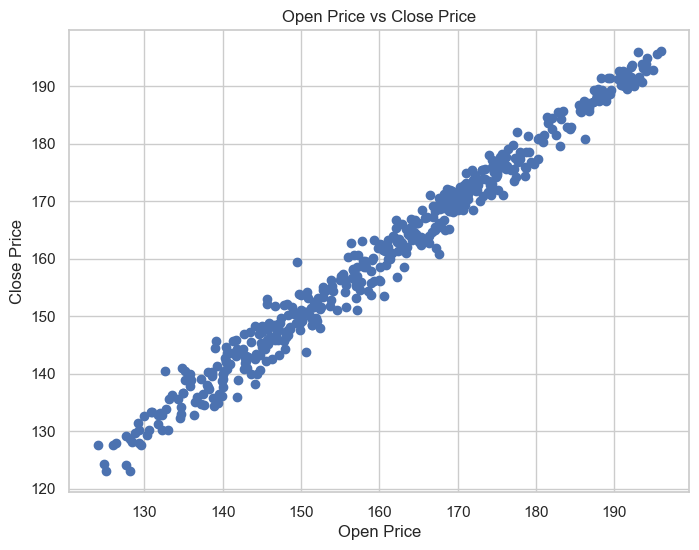

In [46]:
plt.figure(figsize=(8,6))
plt.scatter(df["Open"], df["Close"])
plt.title("Open Price vs Close Price")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.show()

This scatter plot shows the relationship between opening and closing prices. 
Points above the diagonal indicate days where the price increased.

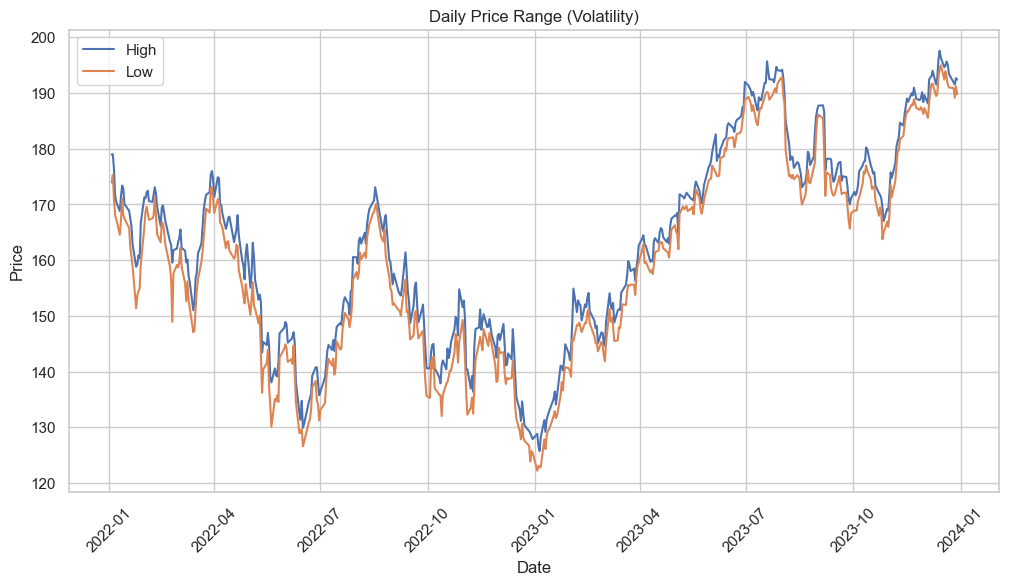

In [47]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["High"], label="High")
plt.plot(df["Date"], df["Low"], label="Low")
plt.title("Daily Price Range (Volatility)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

The gap between high and low prices represents volatility. 
Larger gaps indicate more uncertainty in the market.

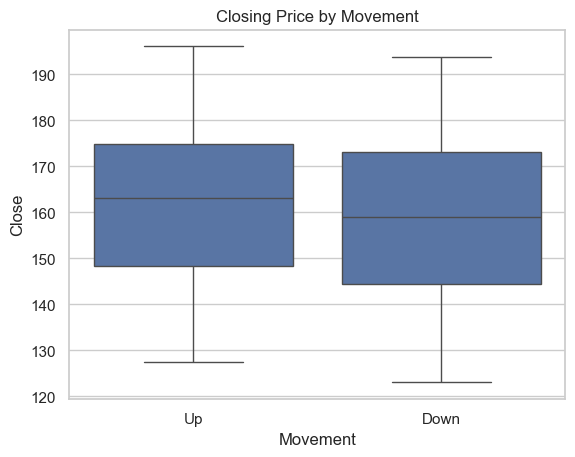

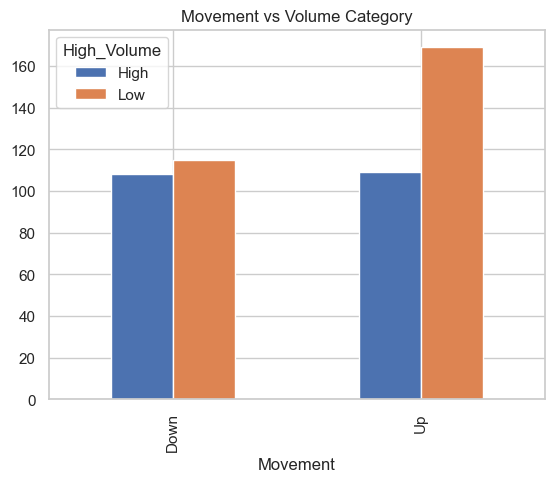

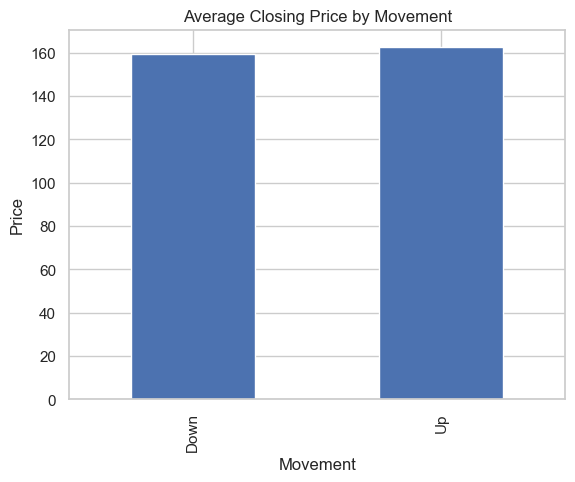

In [52]:
sns.boxplot(x="Movement", y="Close", data=df)
plt.title("Closing Price by Movement")
plt.show()

df["High_Volume"] = np.where(df["Volume"] > df["Volume"].mean(), "High", "Low")

pd.crosstab(df["Movement"], df["High_Volume"]).plot(kind="bar")
plt.title("Movement vs Volume Category")
plt.show()

df.groupby("Movement")["Close"].mean().plot(kind="bar")
plt.title("Average Closing Price by Movement")
plt.ylabel("Price")
plt.show()

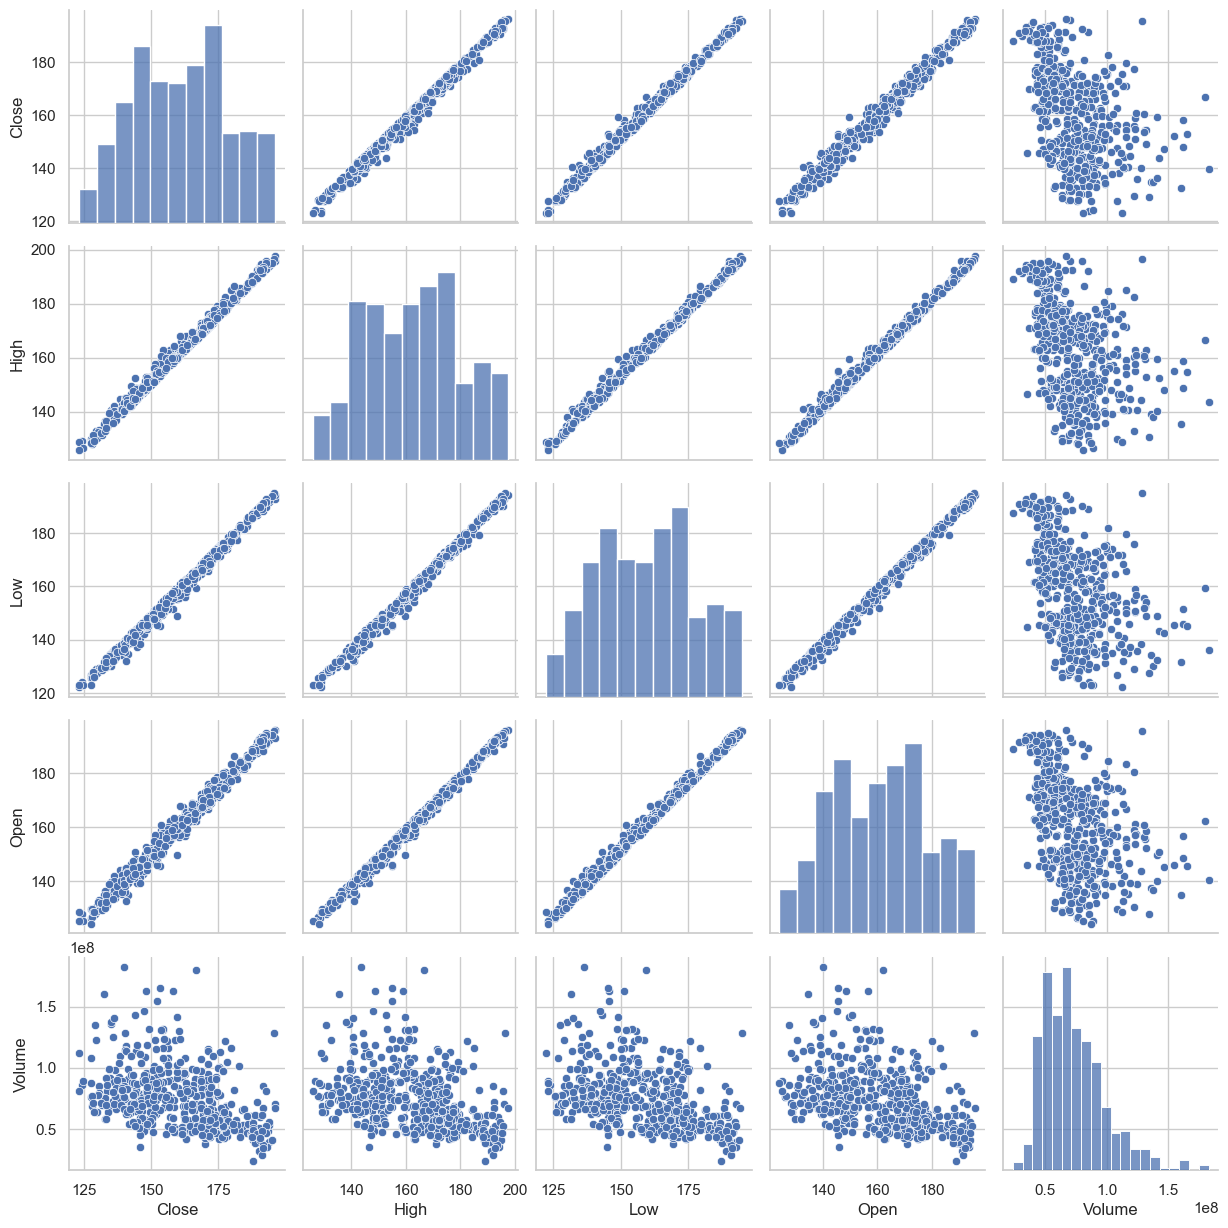

In [53]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

## Conclusion

- The stock shows trends over time with periods of growth and decline.
- Volatility varies, indicating changing market conditions.
- Volume spikes correspond to increased activity.
- Relationships between variables reveal strong correlations.

This EDA provides insight into stock behavior using visual and statistical analysis.